In [18]:
from typing import Annotated, TypedDict
from langchain_groq import ChatGroq
from langgraph.graph import START, END, StateGraph
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_core.tools import tool
from langchain_core.messages import BaseMessage
import os
from dotenv import load_dotenv

In [19]:
load_dotenv()
os.environ['GROQ_API_KEY']=os.getenv('GROQ_API_KEY')
os.environ['LANGSMITH_API_KEY']=os.getenv('LANGSMITH_API_KEY')
os.environ['LANGSMITH_TRACING']="true"

In [20]:
llm = ChatGroq(model="llama-3.3-70b-versatile")
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.5.0', 'langchain': '1.3.14'}}, output_version=None, profile={'name': 'Llama 3.3 70B Versatile', 'release_date': '2024-12-06', 'last_updated': '2024-12-06', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 32768, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000001BC1D22F470>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001BC1D22F740>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [21]:
@tool
def add(a:int, b:int)-> int:
    """Add two numbers"""
    return a+b

tool_node = ToolNode([add])

llm_with_tools = llm.bind_tools([add])

In [22]:
class State(TypedDict):
    messages: Annotated[list[BaseMessage],add_messages]

In [23]:
def call_llm_model(state: State) -> State:
    return {"messages":[llm_with_tools.invoke(state['messages'])]}

In [30]:
graph = StateGraph(State)

graph.add_node("call_llm_model", call_llm_model)
graph.add_node("tools", tool_node)

graph.add_edge(START, "call_llm_model")
graph.add_conditional_edges("call_llm_model", tools_condition)
graph.add_edge("tools", END)

compiled_graph = graph.compile()

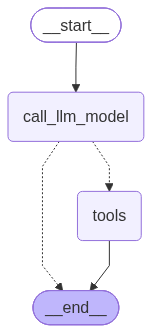

In [31]:
from IPython.display import Image, display

Image(compiled_graph.get_graph().draw_mermaid_png())

In [32]:
response = compiled_graph.invoke({"messages":"What is machine learning?"})

In [33]:
response

{'messages': [HumanMessage(content='What is machine learning?', additional_kwargs={}, response_metadata={}, id='9a065e08-b1f8-4e5a-9c00-a1262c355bdb'),
  AIMessage(content='Machine learning is a subset of artificial intelligence that involves the use of algorithms and statistical models to enable machines to perform tasks without being explicitly programmed. It allows systems to learn from data, identify patterns, and make decisions or predictions based on that data. Machine learning has various applications, including image and speech recognition, natural language processing, and predictive analytics.', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 70, 'prompt_tokens': 217, 'total_tokens': 287, 'completion_time': 0.246684581, 'completion_tokens_details': None, 'prompt_time': 0.020956425, 'prompt_tokens_details': None, 'queue_time': 0.161522073, 'total_time': 0.267641006}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_3272ea2d91', 's

In [34]:
response = compiled_graph.invoke({"messages":"What is 2 + 2?"})

In [35]:
response

{'messages': [HumanMessage(content='What is 2 + 2?', additional_kwargs={}, response_metadata={}, id='c21044ee-c6b7-46ae-a463-cc634924f530'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'jm1a2sc3t', 'function': {'arguments': '{"a":2,"b":2}', 'name': 'add'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 18, 'prompt_tokens': 220, 'total_tokens': 238, 'completion_time': 0.05647253, 'completion_tokens_details': None, 'prompt_time': 0.012398085, 'prompt_tokens_details': None, 'queue_time': 0.050232584, 'total_time': 0.068870615}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f933a-e4f6-71d0-b43e-017017243980-0', tool_calls=[{'name': 'add', 'args': {'a': 2, 'b': 2}, 'id': 'jm1a2sc3t', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 220, 'output_tokens': 18, '

In [36]:
response = compiled_graph.invoke({"messages":"What is 2 plus 2?"})

In [37]:
response

{'messages': [HumanMessage(content='What is 2 plus 2?', additional_kwargs={}, response_metadata={}, id='83999833-a96d-48d7-bd0f-01834241ba85'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '7zww96kfh', 'function': {'arguments': '{"a":2,"b":2}', 'name': 'add'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 18, 'prompt_tokens': 220, 'total_tokens': 238, 'completion_time': 0.059749355, 'completion_tokens_details': None, 'prompt_time': 0.010915022, 'prompt_tokens_details': None, 'queue_time': 0.161842164, 'total_time': 0.070664377}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_45180df409', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f933b-6091-71a0-a926-7ef0d6f989b7-0', tool_calls=[{'name': 'add', 'args': {'a': 2, 'b': 2}, 'id': '7zww96kfh', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 220, 'output_tokens': 1